In [1]:
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import mapclassify
import numpy as np
import seaborn as sns

## Property data

In [ ]:
#skip this block#
#Import affordable housing poperties data

properties_df = pd.read_excel("Active_and_Inconclusive_Properties.xlsx")


In [ ]:
#skip this block#
#save as csv for quicker import 
properties_df.to_csv("affordable_properties.csv", index=False)

In [2]:
#import proprty data from csv
properties_df = pd.read_csv("affordable_properties.csv", low_memory=False)

In [3]:
#select columns 
properties_df = properties_df[[
    "PropertyName",
    "PropertyAddress",
    "City",
    "State",
    "Zip",
    "County",
    "CensusTract",
    "Latitude",
    "Longitude",
    "EarliestConstructionDate",
    "PropertyStatus",
    "ActiveSubsidies",
    "TotalUnits",
    "EarliestEndDate",
    "LatestEndDate",
    "OwnerType",
    "PercentofELIHouseholds",
    "NumberActiveSection8",
    "NumberActiveSection202",
    "NumberActiveSection236",
    "NumberActiveHUDInsured",
    "NumberActiveLihtc",
    "NumberActiveSection515",
    "NumberActiveSection538",
    "NumberActiveHome",
    "NumberActivePublicHousing",
    "NumberActiveState",
    "NumberActivePBV",
    "NumberActiveMR",
    "NumberActiveNHTF"
]]

In [4]:
#Filter only active properties in PG County 
properties_df = properties_df[properties_df["State"] == "MD"]

properties_df = properties_df[properties_df["County"] == "Prince Georges"]

properties_df = properties_df[properties_df['PropertyStatus'] == "Active"]


In [5]:
#reset index
properties_df = properties_df.reset_index(drop=True)

In [6]:
# input missing zip codes 
properties_df.loc[72, "Zip"] = 20737
properties_df.loc[107, "Zip"] = 20740

In [7]:
#convert all zip codes to strings 
properties_df["Zip"] = properties_df["Zip"].astype(int).astype(str)

In [8]:
# fix construction date
properties_df['EarliestConstructionDate'] = pd.to_datetime(
    properties_df['EarliestConstructionDate'],
    errors='coerce'
).dt.year
properties_df['EarliestConstructionDate'] = properties_df['EarliestConstructionDate'].astype('Int64')

In [9]:
#fix end date
properties_df['EarliestEndDate']
properties_df['EarliestEndDate'] = pd.to_datetime(
    properties_df['EarliestEndDate'],
    errors='coerce'
).dt.year
properties_df['EarliestEndDate'] = properties_df['EarliestEndDate'].astype('Int64')


In [10]:
#convert properties_df to a gdf

#create points
property_points = gpd.points_from_xy(properties_df["Longitude"], properties_df["Latitude"])

In [11]:
#create gdf
properties_gdf = gpd.GeoDataFrame(properties_df, geometry=property_points, crs=4326)

In [12]:
# Reproject into UTM 18 North, the local UTM zone (EPSG: 32618)
properties_gdf = properties_gdf.to_crs(32618)

In [13]:
properties_gdf.isna().sum()

PropertyName                  0
PropertyAddress               0
City                          0
State                         0
Zip                           0
County                        0
CensusTract                   0
Latitude                      0
Longitude                     0
EarliestConstructionDate     69
PropertyStatus                0
ActiveSubsidies               0
TotalUnits                    0
EarliestEndDate               8
LatestEndDate                 8
OwnerType                    13
PercentofELIHouseholds       68
NumberActiveSection8          0
NumberActiveSection202        0
NumberActiveSection236        0
NumberActiveHUDInsured        0
NumberActiveLihtc             0
NumberActiveSection515        0
NumberActiveSection538        0
NumberActiveHome              0
NumberActivePublicHousing     0
NumberActiveState             0
NumberActivePBV               0
NumberActiveMR                0
NumberActiveNHTF              0
geometry                      0
dtype: i

graph active subsidies

In [14]:
#count the total of each subsidy type
subsidy_counts = properties_gdf[
    ["NumberActiveSection8",
    "NumberActiveSection202",
    "NumberActiveSection236",
    "NumberActiveHUDInsured",
    "NumberActiveLihtc",
    "NumberActiveSection515",
    "NumberActiveSection538",
    "NumberActiveHome",
    "NumberActivePublicHousing",
    "NumberActiveState",
    "NumberActivePBV",
    "NumberActiveMR",
    "NumberActiveNHTF"]
].sum()

In [15]:
subsidy_counts_df = subsidy_counts.reset_index()
subsidy_counts_df.columns = 'subsidy_type', 'count'
subsidy_counts_df = subsidy_counts_df[subsidy_counts_df['count'] > 0]
subsidy_counts_df = subsidy_counts_df.sort_values(by = "count", ascending=False)

In [16]:
subsidy_counts_df

,subsidy_type,count
4,NumberActiveLihtc,59
0,NumberActiveSection8,52
3,NumberActiveHUDInsured,40
7,NumberActiveHome,19
8,NumberActivePublicHousing,8
10,NumberActivePBV,7
1,NumberActiveSection202,1


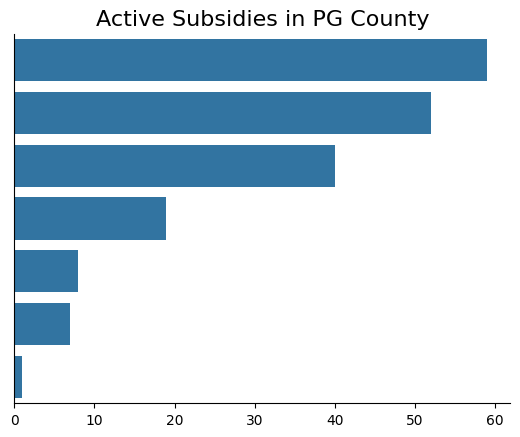

In [17]:
#plot bar chart of subsidy 
ax = sns.barplot(
    data=subsidy_counts_df,
    x='count',
    y='subsidy_type'
)
sns.despine(ax=ax)
ax.set_title('Active Subsidies in PG County', fontsize=16)
ax.set_ylabel(None)
ax.set_xlabel(None)
plt.yticks([])

#plt.savefig(
#    "subsidy_bar_chart.png",
#    dpi=300,
#    bbox_inches='tight'
#)

plt.show()



graph histogram of year built 

In [18]:
year_built_gdf = properties_gdf.dropna(subset=['EarliestConstructionDate'])

<function matplotlib.pyplot.show(close=None, block=None)>

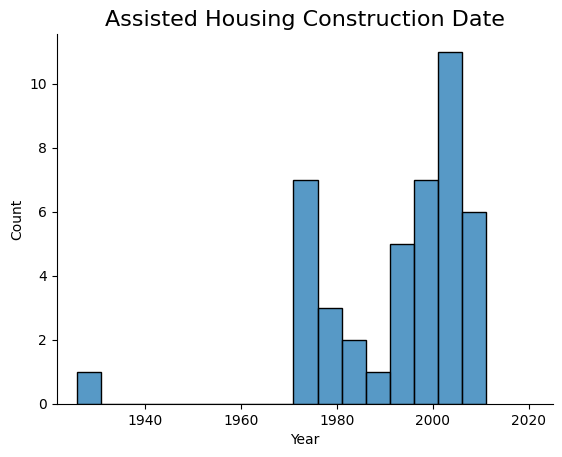

In [19]:
ax = sns.histplot(
    data=year_built_gdf,
    x='EarliestConstructionDate',
    binwidth=5
)

sns.despine(ax=ax)
ax.set_title('Assisted Housing Construction Date', fontsize=16)
ax.set_xlabel('Year')
ax.set_xlim(right=2025)

#plt.savefig(
#    "construction_year_hist.png",
#    dpi=300,
#    bbox_inches='tight'
#)

plt.show

graph expiration years

In [20]:
expiration_gdf = properties_gdf.dropna(subset=['EarliestEndDate'])

<function matplotlib.pyplot.show(close=None, block=None)>

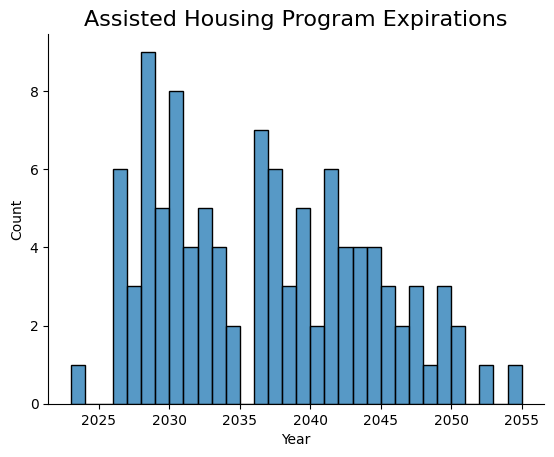

In [21]:
ax = sns.histplot(
    data=expiration_gdf,
    x='EarliestEndDate',
    binwidth=1
)

sns.despine(ax=ax)
ax.set_title('Assisted Housing Program Expirations', fontsize=16)
ax.set_xlabel('Year')

#plt.savefig(
#    "program_expiration_hist.png",
#    dpi=300,
#    bbox_inches='tight'
#)

plt.show

## Prepare overlay and attributes

Income data

In [32]:
#import 2024 income data
acs_income_gdf = gpd.read_file("acs2024_5yr_B19013_14000US24033803606.geojson")
acs_income_gdf = acs_income_gdf.to_crs(32618)

In [33]:
acs_income_gdf.head()

,geoid,name,B19013001,"B19013001, Error",geometry
0,05000US24033,"Prince George's County, MD",101798.0,1449.0,"MULTIPOLYGON (((332494.046 4308621.237, 332487..."
1,14000US24033800102,"Census Tract 8001.02, Prince George's, MD",80745.0,11830.0,"MULTIPOLYGON (((338547.989 4330239.108, 338554..."
2,14000US24033800103,"Census Tract 8001.03, Prince George's, MD",87008.0,17623.0,"MULTIPOLYGON (((339824.979 4329614.05, 339886...."
3,14000US24033800105,"Census Tract 8001.05, Prince George's, MD",109709.0,16408.0,"MULTIPOLYGON (((336571.745 4329572.268, 336607..."
4,14000US24033800106,"Census Tract 8001.06, Prince George's, MD",135119.0,24886.0,"MULTIPOLYGON (((336209.349 4328432.396, 336262..."


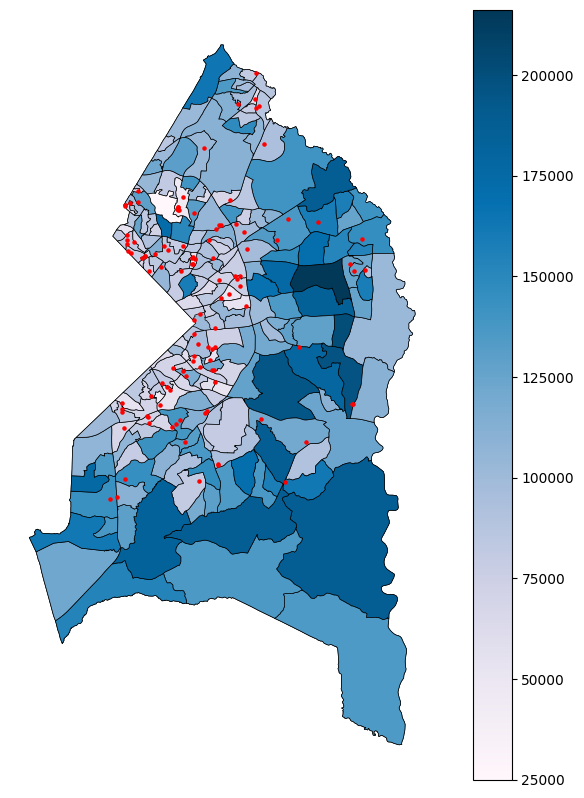

In [34]:
fig, ax = plt.subplots(figsize=(10, 10))
ax = acs_income_gdf.plot(ax=ax, column='B19013001', cmap='PuBu', linewidth=0.5, edgecolor='black', legend=True)
properties_gdf.plot(ax=ax, markersize=5, color='r', zorder=1)
ax.axis('off')

#plt.savefig(
#    "income_map.png",
#    dpi=300,
#    bbox_inches='tight'
#)

plt.show()

Rent data

In [35]:
#import 2024 acs data
acs2024_gdf = gpd.read_file("acs2024_5yr_B25064_14000US24033803606.geojson")

In [36]:
# Reproject into UTM 18 North, the local UTM zone (EPSG: 32618)
acs2024_gdf = acs2024_gdf.to_crs(32618)

In [37]:
#rename columns
acs2024_gdf = acs2024_gdf.rename(columns={"name": "census_tract","B25064001": "median_rent_2024", "B25064001, Error": "median_rent_2024_se"})

In [38]:
#create a column with just the tract number
acs2024_gdf["tract_id"] = (acs2024_gdf["census_tract"].str.split().str[2].str.replace(",", "", regex=False))

In [39]:
#convert column from object to string 
acs2024_gdf["tract_id"] = acs2024_gdf["tract_id"].astype(str)

# 10 Year Assessment 

In [40]:
#filter properties expiring in the next 10 years 
properties_df = properties_df[properties_df['EarliestEndDate'] < 2037]

In [41]:
len(properties_df)

54

In [42]:
#convert properties_df to a gdf

#create points
property_points = gpd.points_from_xy(properties_df["Longitude"], properties_df["Latitude"])

In [43]:
#create gdf
properties_gdf = gpd.GeoDataFrame(properties_df, geometry=property_points, crs=4326)

In [44]:
# Reproject into UTM 18 North, the local UTM zone (EPSG: 32618)
properties_gdf = properties_gdf.to_crs(32618)

graph owners for proprties expiring in the next 10 years

In [45]:
properties_gdf['OwnerType'] = (properties_gdf['OwnerType'].str.title())

In [46]:
properties_gdf['OwnerType'].value_counts()

OwnerType
For Profit          24
Non-Profit          12
Profit Motivated     5
Multiple             2
Limited Dividend     1
Name: count, dtype: int64

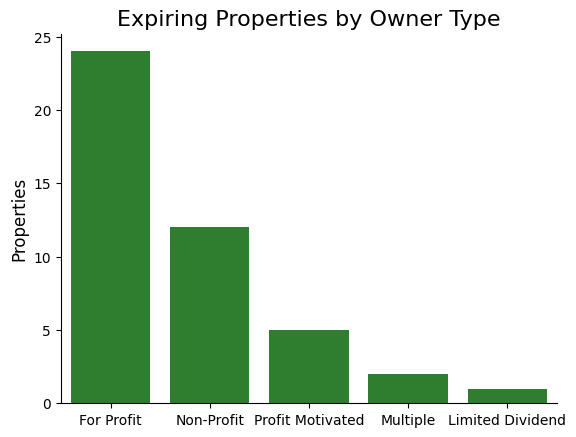

In [47]:
ax = sns.countplot(properties_gdf, x='OwnerType', order=properties_gdf['OwnerType'].value_counts().index, color='forestgreen')
sns.despine(ax=ax)
ax.set_title('Expiring Properties by Owner Type', fontsize=16)
ax.set_ylabel('Properties', fontsize=12)
ax.set_xlabel(None)

#plt.savefig(
#    "owner_chart_10yr.png",
#    dpi=300,
#    bbox_inches='tight'
#)


plt.show()

graph subsidies expiring in the next 10 years

In [48]:
subsidy_counts = properties_gdf[
    ["NumberActiveSection8",
    "NumberActiveSection202",
    "NumberActiveSection236",
    "NumberActiveHUDInsured",
    "NumberActiveLihtc",
    "NumberActiveSection515",
    "NumberActiveSection538",
    "NumberActiveHome",
    "NumberActivePublicHousing",
    "NumberActiveState",
    "NumberActivePBV",
    "NumberActiveMR",
    "NumberActiveNHTF"]
].sum()

In [49]:
subsidy_counts_df = subsidy_counts.reset_index()
subsidy_counts_df.columns = 'subsidy_type', 'count'
subsidy_counts_df = subsidy_counts_df[subsidy_counts_df['count'] > 0]
subsidy_counts_df = subsidy_counts_df.sort_values(by = "count", ascending=False)

In [50]:
subsidy_counts_df

,subsidy_type,count
4,NumberActiveLihtc,42
3,NumberActiveHUDInsured,28
0,NumberActiveSection8,17
7,NumberActiveHome,14
1,NumberActiveSection202,1


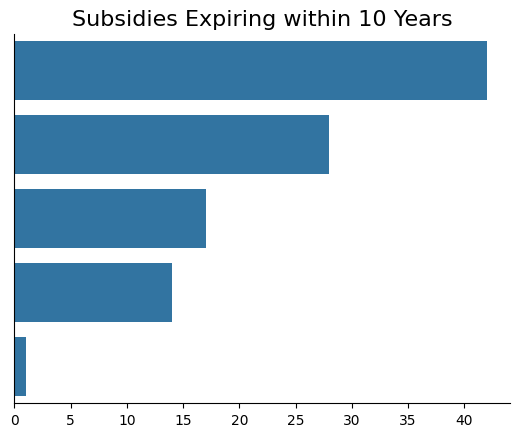

In [51]:
#plot bar chart of subsidy 
ax = sns.barplot(
    data=subsidy_counts_df,
    x='count',
    y='subsidy_type'
)
sns.despine(ax=ax)
ax.set_title('Subsidies Expiring within 10 Years', fontsize=16)
ax.set_ylabel(None)
ax.set_xlabel(None)
plt.yticks([])

#plt.savefig(
#    "subsidy_bar_chart_10yr.png",
#    dpi=300,
#    bbox_inches='tight'
#)

plt.show()



create map of high risk properties 

In [52]:
acs2024_gdf['median_rent_2024'].describe()

count     200.000000
mean     1982.245000
std       506.495165
min       845.000000
25%      1658.500000
50%      1811.500000
75%      2276.500000
max      3501.000000
Name: median_rent_2024, dtype: float64

In [53]:
#identify census tracts with rent above the median in the county 
top50_gdf = acs2024_gdf[acs2024_gdf['median_rent_2024'] > 1811.5]

In [54]:
# filter only for-profit properties 
properties_profit_gdf = properties_gdf[properties_gdf['OwnerType'] == 'For Profit']

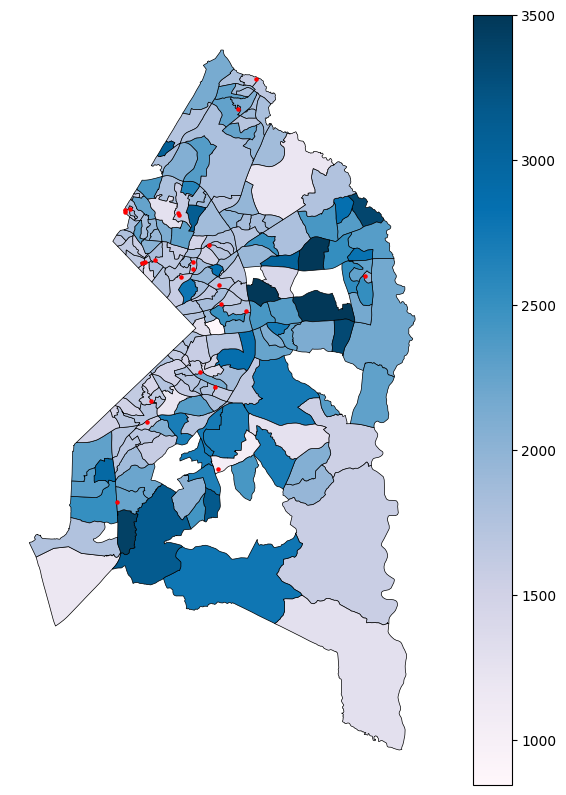

In [55]:
#for-profit properties expiring in the next 10 years
fig, ax = plt.subplots(figsize=(10, 10))
ax = acs2024_gdf.plot(ax=ax, column='median_rent_2024', cmap='PuBu', linewidth=0.5, edgecolor='black', legend=True)
properties_profit_gdf.plot(ax=ax, markersize=5, color='r', zorder=1)
ax.axis('off')

#plt.savefig(
#    "profit_10yr_map.png",
#    dpi=300,
#    bbox_inches='tight'
#)

plt.show()

In [56]:
#prform spatial join to return properties with for-profit owners in census tracts with above median rent 
high_risk_properties = gpd.sjoin(properties_profit_gdf, top50_gdf, predicate='within')

In [57]:
high_risk_properties.head().T

,59,64,68
PropertyName,FTWASHINTON MANOR APARTMENTS,PIN OAK VILLAGE II,LAUREL LAKES APARTMENTS
PropertyAddress,10850 Indian Head Hwy,16010 Excalibur Rd,7901 Laurel Lakes Ct
City,Fort Washington,Bowie,Laurel
State,MD,MD,MD
Zip,20744,20716,20707
County,Prince Georges,Prince Georges,Prince Georges
CensusTract,24033801313.0,24033800520.0,24033800212.0
Latitude,38.742954,38.940697,39.080935
Longitude,-76.991375,-76.725545,-76.868004
EarliestConstructionDate,<NA>,<NA>,<NA>


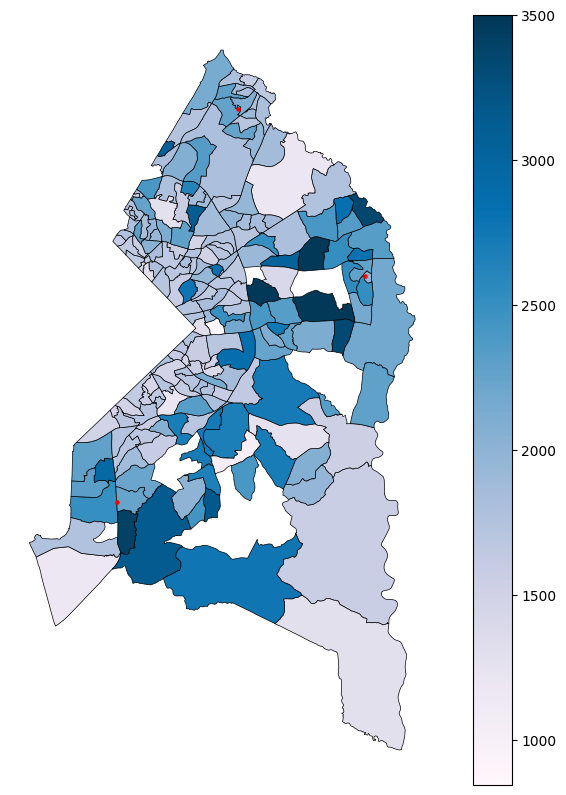

In [58]:
fig, ax = plt.subplots(figsize=(10, 10))
ax = acs2024_gdf.plot(ax=ax, column='median_rent_2024', cmap='PuBu', linewidth=0.5, edgecolor='black', legend=True)
high_risk_properties.plot(ax=ax, markersize=5, color='r', zorder=1)
ax.axis('off')

plt.savefig(
    "high_risk_10yr_map.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()